In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [3]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df = pd.get_dummies(
    df,
    columns=['ocean_proximity'],
    drop_first=True
)

In [9]:
y = df['median_house_value']

X = df.drop(
    'median_house_value',
    axis=1
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-27108.75,-25657.81, 1081.36,...,213653.37, -6232.42, 3166.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.299e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [12]:
y_pred = model.predict(X_test)

In [13]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MSE =", mse)
print("RMSE =", rmse)
print("MAE =", mae)
print("R2 =", r2)

MSE = 4802173538.60417
RMSE = 69297.71669113038
MAE = 50413.43330810068
R2 = 0.6488402154431986


In [14]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)


,Actual,Predicted
14416,245800,201882.959868
16383,137900,147279.682144
7731,218200,207796.609798
1410,220800,180487.576722
1335,170500,190323.923130
16260,75000,95437.897104
18011,269400,287156.451612
10086,228900,257624.771805
18294,500001,385383.556151
18733,80800,62548.197551


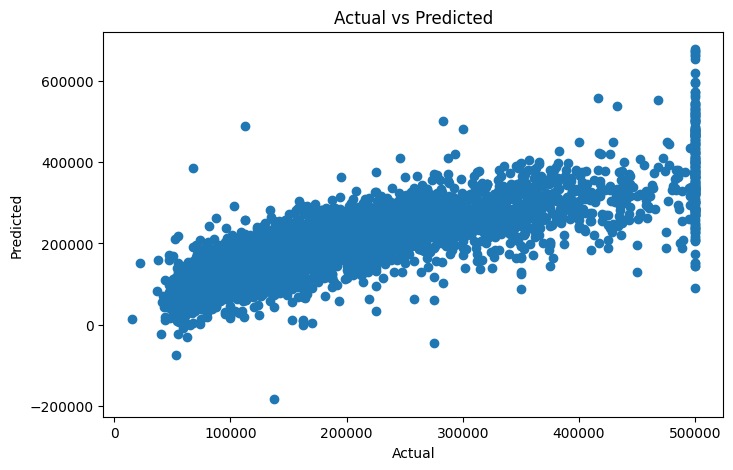

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

# Task 2: Compare One-Feature and Multi-Feature Models

In [16]:
X_A = df[['median_income']]

In [17]:
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model_A = LinearRegression()

model_A.fit(
    X_train_A,
    y_train_A
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41751.96]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.504e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [19]:
pred_A = model_A.predict(
    X_test_A
)


In [20]:
mse_A = mean_squared_error(
    y_test_A,
    pred_A
)

rmse_A = np.sqrt(mse_A)

mae_A = mean_absolute_error(
    y_test_A,
    pred_A
)

r2_A = r2_score(
    y_test_A,
    pred_A
)

print("MSE =", mse_A)
print("RMSE =", rmse_A)
print("MAE =", mae_A)
print("R2 =", r2_A)

MSE = 7221011204.235033
RMSE = 84976.53325615863
MAE = 63374.551304332555
R2 = 0.47196228574894983


In [21]:
X_B = df[
    [
        'median_income',
        'housing_median_age',
        'total_rooms'
    ]
]

In [22]:
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
model_B = LinearRegression()

model_B.fit(
    X_train_B,
    y_train_B
)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[42440.08, 1959.31, 3.82]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['median_income','housing_median_age','total_rooms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.374e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [24]:
pred_B = model_B.predict(
    X_test_B
)

In [25]:
mse_B = mean_squared_error(
    y_test_B,
    pred_B
)

rmse_B = np.sqrt(mse_B)

mae_B = mean_absolute_error(
    y_test_B,
    pred_B
)

r2_B = r2_score(
    y_test_B,
    pred_B
)

print("MSE =", mse_B)
print("RMSE =", rmse_B)
print("MAE =", mae_B)
print("R2 =", r2_B)

MSE = 6649671695.107482
RMSE = 81545.51916020575
MAE = 60939.7973070972
R2 = 0.5137415878339671


In [26]:
comparison_table = pd.DataFrame({
    "Model": ["Model A", "Model B"],
    "MSE": [mse_A, mse_B],
    "RMSE": [rmse_A, rmse_B],
    "MAE": [mae_A, mae_B],
    "R2": [r2_A, r2_B]
})

comparison_table

,Model,MSE,RMSE,MAE,R2
0,Model A,7.221011e+09,84976.533256,63374.551304,0.471962
1,Model B,6.649672e+09,81545.519160,60939.797307,0.513742


## Result

Model B performed better than Model A because it uses multiple features for prediction.

Model B achieved:
- Lower error values (MSE, RMSE, MAE)
- Higher R² score

Therefore, Model B is selected as the better model.

# Task 3: Test Different Train/Test Splits

In [27]:
results = []


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_B,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

results.append([
    "80/20",

    mean_squared_error(y_train, train_pred),
    np.sqrt(mean_squared_error(y_train, train_pred)),
    mean_absolute_error(y_train, train_pred),
    r2_score(y_train, train_pred),

    mean_squared_error(y_test, test_pred),
    np.sqrt(mean_squared_error(y_test, test_pred)),
    mean_absolute_error(y_test, test_pred),
    r2_score(y_test, test_pred)
])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_B,
    y,
    test_size=0.3,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

results.append([
    "70/30",

    mean_squared_error(y_train, train_pred),
    np.sqrt(mean_squared_error(y_train, train_pred)),
    mean_absolute_error(y_train, train_pred),
    r2_score(y_train, train_pred),

    mean_squared_error(y_test, test_pred),
    np.sqrt(mean_squared_error(y_test, test_pred)),
    mean_absolute_error(y_test, test_pred),
    r2_score(y_test, test_pred)
])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_B,
    y,
    test_size=0.4,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

results.append([
    "60/40",

    mean_squared_error(y_train, train_pred),
    np.sqrt(mean_squared_error(y_train, train_pred)),
    mean_absolute_error(y_train, train_pred),
    r2_score(y_train, train_pred),

    mean_squared_error(y_test, test_pred),
    np.sqrt(mean_squared_error(y_test, test_pred)),
    mean_absolute_error(y_test, test_pred),
    r2_score(y_test, test_pred)
])

In [31]:
split_results = pd.DataFrame(
    results,
    columns=[
        "Split",
        "Train_MSE",
        "Train_RMSE",
        "Train_MAE",
        "Train_R2",
        "Test_MSE",
        "Test_RMSE",
        "Test_MAE",
        "Test_R2"
    ]
)

split_results

,Split,Train_MSE,Train_RMSE,Train_MAE,Train_R2,Test_MSE,Test_RMSE,Test_MAE,Test_R2
0,80/20,6.431277e+09,80195.244894,59829.519649,0.514139,6.649672e+09,81545.519160,60939.797307,0.513742
1,70/30,6.477110e+09,80480.494639,59986.594277,0.513785,6.470192e+09,80437.505323,60418.871353,0.514648
2,60/40,6.580977e+09,81123.218939,60410.532530,0.510330,6.316586e+09,79476.950516,59750.081746,0.519697


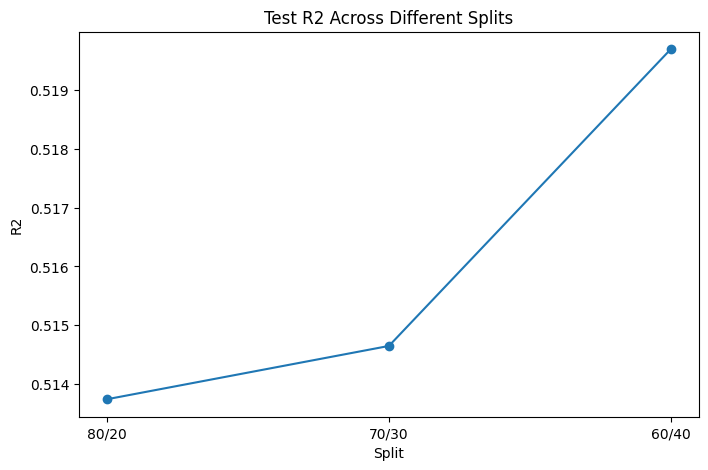

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    split_results["Split"],
    split_results["Test_R2"],
    marker='o'
)

plt.title("Test R2 Across Different Splits")

plt.xlabel("Split")

plt.ylabel("R2")

plt.show()

## Result

The train and test scores are close to each other, showing that the model is stable.

The split with the highest Test R² and lowest test errors provides the most reliable performance.

# Task 4: Metric Verification and Exploration


In [33]:
errors = y_test - test_pred

manual_mse = np.mean(errors**2)

manual_rmse = np.sqrt(manual_mse)

manual_mae = np.mean(np.abs(errors))

In [34]:
ss_res = np.sum((y_test - test_pred)**2)

ss_tot = np.sum(
    (y_test - np.mean(y_test))**2
)

manual_r2 = 1 - (
    ss_res / ss_tot
)


In [35]:
print("Manual MSE =", manual_mse)
print("Manual RMSE =", manual_rmse)
print("Manual MAE =", manual_mae)
print("Manual R2 =", manual_r2)

Manual MSE = 6316585663.320914
Manual RMSE = 79476.95051598869
Manual MAE = 59750.08174621193
Manual R2 = 0.5196970562615739


In [36]:
from sklearn.metrics import median_absolute_error

medae = median_absolute_error(
    y_test,
    test_pred
)

print("Median Absolute Error =", medae)


Median Absolute Error = 47850.48811332615


In [37]:
metric_table = pd.DataFrame({
    "Metric":[
        "MSE",
        "RMSE",
        "MAE",
        "R2",
        "Median Absolute Error"
    ],

    "Value":[
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2,
        medae
    ]
})

metric_table


,Metric,Value
0,MSE,6.316586e+09
1,RMSE,7.947695e+04
2,MAE,5.975008e+04
3,R2,5.196971e-01
4,Median Absolute Error,4.785049e+04


In [38]:
modified_pred = test_pred.copy()

modified_pred[:3] += 300000

In [39]:
new_mse = mean_squared_error(
    y_test,
    modified_pred
)

new_rmse = np.sqrt(new_mse)

new_mae = mean_absolute_error(
    y_test,
    modified_pred
)

print("New MSE =", new_mse)
print("New RMSE =", new_rmse)
print("New MAE =", new_mae)

New MSE = 6344899587.651171
New RMSE = 79654.87799031
New MAE = 59830.62430226521


## Observation

After adding three large prediction errors:

- MSE increased significantly.
- RMSE also increased sharply.
- MAE increased but less dramatically.

### Conclusion

MSE is the most sensitive metric to large errors because it squares the errors.

RMSE is also strongly affected.

MAE is less sensitive and more robust against outliers.